# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1 - adding a penalty that grows with parameter size forces the model to keep coefficients small so making it not fit as much noise in the training data and bettering generalization
2 - Increasing the regularization penalty increases bias by constraining the model but reduces variance by preventing overfitting, so tuning the penalty lets you navigate the tradeoff.
3 - lasso uses an absolute value penalty and tends to shrink some coefficients all the way to zero, effectively selecting features, while Ridge uses a squared penalty and shrinks all coefficients toward zero without eliminating any.
4 - Variables are usuaully standardized to have mean 0 and standard deviation 1 so that the penalty treats all features equally, regardless of their original scale.
5 - The penalty a is typically selected using cross validation by choosing the value that minimizes the cross validated prediction error.
6 - No- you evaluate cross validated mse without the penalty term, because you want to measure true prediction error on held-out data rather than the regularized training objective.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

   Mileage_Run       Age  Mileage_Run^2  Mileage_Run Age     Age^2  \
0     0.124692 -0.013092      -0.137673        -0.045119 -0.157264   
1    -0.872334  0.341858      -0.791316        -0.677034  0.190081   
2    -0.493517 -0.722993      -0.600623        -0.665157 -0.742267   
3    -0.241655 -0.013092      -0.434732        -0.301067 -0.157264   
4    -0.674578 -0.013092      -0.700583        -0.603528 -0.157264   

   Mileage_Run^3  Mileage_Run^2 Age  Mileage_Run Age^2     Age^3  
0      -0.294615          -0.230767          -0.195586 -0.270422  
1      -0.661216          -0.718186          -0.564890  0.044089  
2      -0.581863          -0.648004          -0.700911 -0.718398  
3      -0.492295          -0.458906          -0.364354 -0.270422  
4      -0.627064          -0.663078          -0.563792 -0.270422  
             Feature   Coefficient
0        Mileage_Run  9.117748e+05
7  Mileage_Run Age^2  7.167816e+05
4              Age^2  3.505507e+05
6  Mileage_Run^2 Age  3.388195e+05
5 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.215e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.201e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the numb

Optimal Alpha: 93.2603

Lasso Coefficients:
             Feature   Coefficient
0        Mileage_Run  7.743713e+05
7  Mileage_Run Age^2  5.376881e+05
6  Mileage_Run^2 Age  2.667562e+05
8              Age^3  1.427963e+04
4              Age^2  0.000000e+00
5      Mileage_Run^3 -4.090546e+04
1                Age -1.355073e+05
2      Mileage_Run^2 -2.005779e+05
3    Mileage_Run Age -1.311067e+06

Intercept: 741019.4672


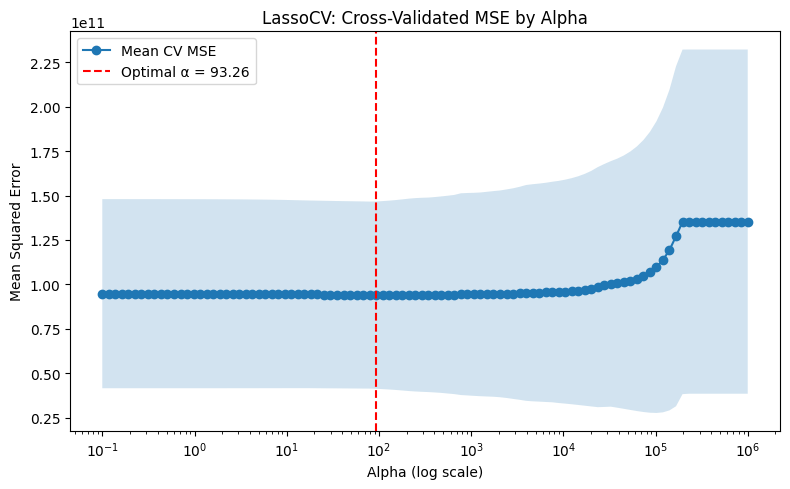

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.233e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.213e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

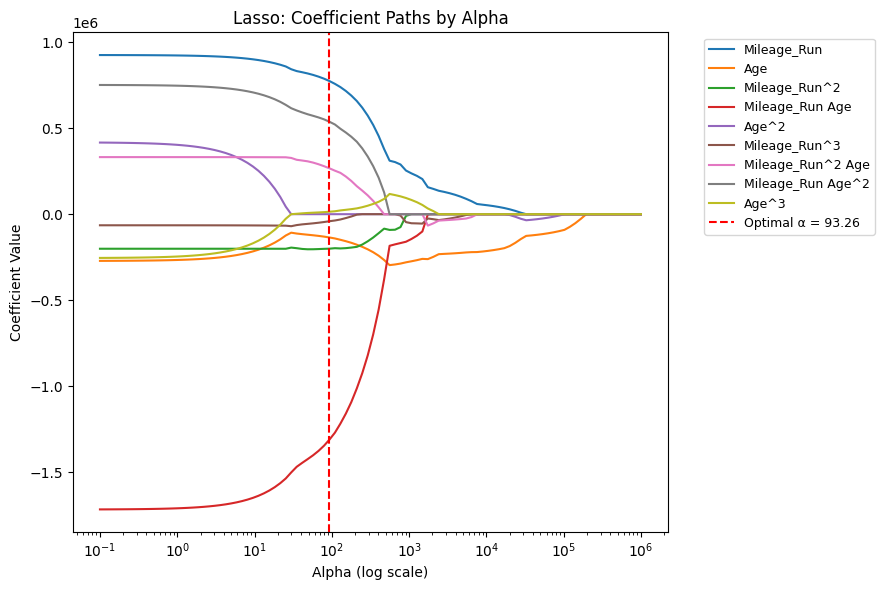

=== Selected Features ===
          Feature   Coefficient
      Mileage_Run  7.743713e+05
Mileage_Run Age^2  5.376881e+05
Mileage_Run^2 Age  2.667562e+05
            Age^3  1.427963e+04
    Mileage_Run^3 -4.090546e+04
              Age -1.355073e+05
    Mileage_Run^2 -2.005779e+05
  Mileage_Run Age -1.311067e+06

=== Summary ===
Total features:    9
Selected (nonzero): 8
Zeroed out:        1
Proportion zeroed: 11.11%
          Feature  OLS Coefficient  Lasso Coefficient  Magnitude Change  Sign Change
      Mileage_Run     9.117748e+05       7.743713e+05    -137403.507406        False
              Age    -2.481722e+05      -1.355073e+05    -112664.884998        False
    Mileage_Run^2    -2.072926e+05      -2.005779e+05      -6714.749887        False
  Mileage_Run Age    -1.671212e+06      -1.311067e+06    -360145.197163        False
            Age^2     3.505507e+05       0.000000e+00    -350550.719877         True
    Mileage_Run^3    -6.514490e+04      -4.090546e+04     -24239.4322

In [20]:
#1
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from datetime import datetime
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

df = pd.read_csv('data/cars_hw.csv')

current_year = datetime.now().year
df['Age'] = current_year - df['Make_Year']


X = df[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
X_final = pd.DataFrame(X_scaled, columns=feature_names)
print(X_final.head())

#2
y = df['Price']

lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df)
print(f"\nIntercept: {lr.intercept_:.4f}")

interaction_coef = coef_df[coef_df['Feature'] == 'Mileage_Run Age']['Coefficient'].values[0]
print(f"\nInteraction (Mileage_Run x Age) coefficient: {interaction_coef:.4f}")
print(f"Sign: {'Positive' if interaction_coef > 0 else 'Negative'}")
#the interaction term mile run x age has a negative sign (-1671.212)
# means that with everything else constant, cars that are high milage and old have a large additional price penalty (compound)
# so old car thats getting worn down over time has price cut, which makes sense
#it being the dominant coeffficent suggests that its the most important feature interaction in the model

# 3
alphas = np.logspace(-1, 6, 100)

lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"Optimal Alpha: {lasso_cv.alpha_:.4f}")
lasso_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_cv.coef_
}).sort_values('Coefficient', ascending=False)

print("\nLasso Coefficients:")
print(lasso_coef_df)
print(f"\nIntercept: {lasso_cv.intercept_:.4f}")

import warnings
from sklearn.exceptions import ConvergenceWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=42, max_iter=10000)
    lasso_cv.fit(X_scaled, y)

# 4 and 5

mse_mean = np.mean(lasso_cv.mse_path_, axis=1)  # average over folds
mse_std  = np.std(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mse_mean, 'o-', label='Mean CV MSE')
plt.fill_between(lasso_cv.alphas_, mse_mean - mse_std, mse_mean + mse_std,
                 alpha=0.2)
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Optimal α = {lasso_cv.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('LassoCV: Cross-Validated MSE by Alpha')
plt.legend()
plt.tight_layout()
plt.show()

coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(9, 6))
for i, name in enumerate(feature_names):
    plt.plot(alphas, coefs[:, i], label=name)

plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Optimal α = {lasso_cv.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso: Coefficient Paths by Alpha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

#6

lasso_final = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_cv.coef_
})

selected     = lasso_final[lasso_final['Coefficient'] != 0]
zeroed_out   = lasso_final[lasso_final['Coefficient'] == 0]

print("=== Selected Features ===")
print(selected.sort_values('Coefficient', ascending=False).to_string(index=False))

print(f"\n=== Summary ===")
print(f"Total features:    {len(lasso_final)}")
print(f"Selected (nonzero): {len(selected)}")
print(f"Zeroed out:        {len(zeroed_out)}")
print(f"Proportion zeroed: {len(zeroed_out)/len(lasso_final):.2%}")
# only one feature was eliminated, so 8/9 features survived (8 are still selected) - Age^2 was the one eliminated

#7

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': lr.coef_,
    'Lasso Coefficient': lasso_cv.coef_
})

comparison_df['Magnitude OLS']   = np.abs(comparison_df['OLS Coefficient'])
comparison_df['Magnitude Lasso'] = np.abs(comparison_df['Lasso Coefficient'])
comparison_df['Magnitude Change'] = comparison_df['Magnitude Lasso'] - comparison_df['Magnitude OLS']
comparison_df['Sign OLS']   = np.sign(comparison_df['OLS Coefficient'])
comparison_df['Sign Lasso'] = np.sign(comparison_df['Lasso Coefficient'])
comparison_df['Sign Change'] = comparison_df['Sign OLS'] != comparison_df['Sign Lasso']

print(comparison_df[['Feature', 'OLS Coefficient', 'Lasso Coefficient', 
                       'Magnitude Change', 'Sign Change']].to_string(index=False))

print("\n=== Features that INCREASED in magnitude ===")
print(comparison_df[comparison_df['Magnitude Change'] > 0][['Feature', 'OLS Coefficient', 'Lasso Coefficient']])

print("\n=== Features that CHANGED sign ===")
print(comparison_df[comparison_df['Sign Change']][['Feature', 'OLS Coefficient', 'Lasso Coefficient']])

# based on this code output, none of them increased in magnitude (all negative, so shrank or got zeroed out)
# one of the features did change sign, age^2, but thats a special case bc it was zeroed out totally, and zero
# coefficient has technically no sign. 
# no other coefficients changed sign, meaning OLS was getting the direction of each effect correct,
# just inflating the magnitudes due to multicollinearity.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

                               Feature  Coefficient
                   ejection_fraction^2     3.317931
    ejection_fraction serum_creatinine     2.604767
                                 age^3     1.889040
                  age serum_creatinine     1.680570
                                   age     1.549928
                age serum_creatinine^2     1.433246
  ejection_fraction serum_creatinine^2     1.217335
               age^2 ejection_fraction     1.022027
                      diabetes smoking     0.101527
          diabetes high_blood_pressure     0.099245
           high_blood_pressure smoking     0.064240
                      anaemia diabetes     0.052542
                       anaemia smoking     0.044219
               age ejection_fraction^2     0.017577
           anaemia high_blood_pressure     0.014944
   anaemia high_blood_pressure smoking    -0.005887
                    serum_creatinine^3    -0.014908
                               anaemia    -0.021505
            

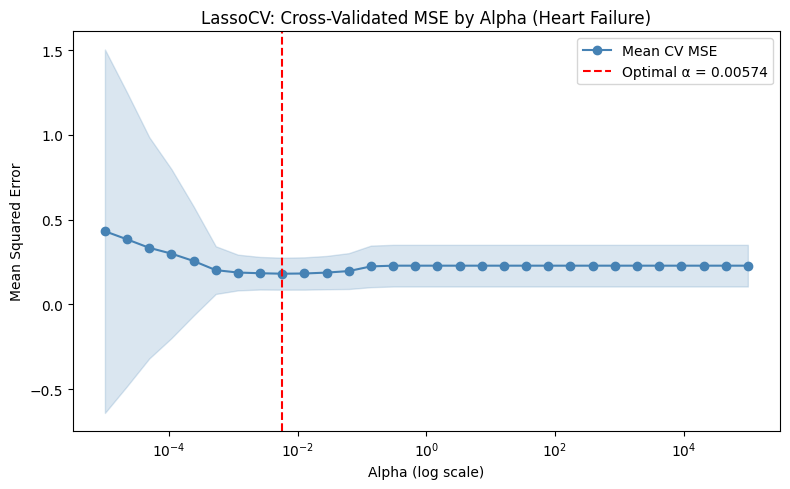

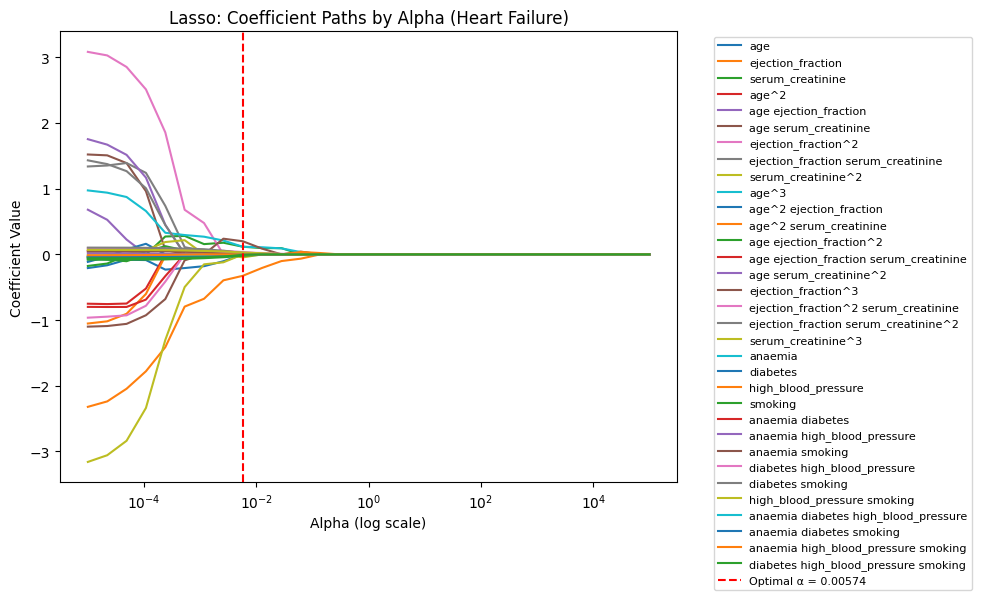

=== Selected Features ===
                             Feature  OLS Coefficient  Lasso Coefficient
                   ejection_fraction        -2.025371          -0.326260
                    serum_creatinine        -0.739027           0.116836
                               age^3         1.889040           0.116097
                 ejection_fraction^3        -1.253594           0.200132
ejection_fraction^2 serum_creatinine        -1.219271           0.035397
                  serum_creatinine^3        -0.014908          -0.045957
                             anaemia        -0.021505           0.013051
                             smoking        -0.078535          -0.020900
        diabetes high_blood_pressure         0.099245           0.026322
                    diabetes smoking         0.101527           0.020528
         high_blood_pressure smoking         0.064240           0.028936
            anaemia diabetes smoking        -0.038432          -0.000207
diabetes high_blood_press

In [ ]:
#1
df = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')

X = df[['age', 'ejection_fraction', 'serum_creatinine']]
y = df['DEATH_EVENT']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X2 = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly2 = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)
X_poly2 = poly2.fit_transform(X2)

scaler2 = StandardScaler()
X_final = np.hstack([X_scaled, scaler2.fit_transform(X_poly2)])

#2
lr2 = LinearRegression()
lr2.fit(X_final, y)

feature_names_continuous = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
feature_names_binary = poly2.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
all_feature_names = np.concatenate([feature_names_continuous, feature_names_binary])

coef_df2 = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr2.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df2.to_string(index=False))
print(f"\nIntercept: {lr2.intercept_:.4f}")
# honestly, some of these seem pretty intuitive (ex age having positive coefficent, older is more likely to die,
# diabetes and smoking being positive makes sense) HOWEVER, a lot dont seem that way - smoking, anemia, hpb, all have
# very small yet negative coefficents. thats pretty counterintuitive to me, as all of them are associated with poor health.
# its strange however that age^2 is strongly negative, indicating that older age reduced death risk (not logical)
# these sign contradictions seem to be classic symptom of colinerity, when age^1^2^3 are all in the model at
# the same time, ols is trying to solve a system where the three terms together trace out the right curve — 
# but it compensates by assigning counteracting signs to individual terms. No single coefficient is meant to be interpreted 
# in isolation
# how higher order terms resolve - 
# the combo of age + age^2 + age^3 together can represent a flexible nonlinear curve that might increase 
# steeply at first then level off or accelerate at older ages, patterns a single linear term could never 
# capture. The apparent contradiction dissolves when you think of the three terms as a team describing one curve, 
# rather than three independent effects

# 3
import warnings
from sklearn.exceptions import ConvergenceWarning

alphas2 = np.logspace(-5, 5, 30)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    lasso_cv2 = LassoCV(alphas=alphas2, cv=20, random_state=42, max_iter=10000)
    lasso_cv2.fit(X_final, y)

print(f"Optimal Alpha: {lasso_cv2.alpha_:.6f}")

lasso_coef_df2 = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lasso_cv2.coef_
}).sort_values('Coefficient', ascending=False)

print("\nLasso Coefficients:")
print(lasso_coef_df2.to_string(index=False))
print(f"\nIntercept: {lasso_cv2.intercept_:.4f}")

# 4 and 5

mse_mean2 = np.mean(lasso_cv2.mse_path_, axis=1)
mse_std2  = np.std(lasso_cv2.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv2.alphas_, mse_mean2, 'o-', color='steelblue', label='Mean CV MSE')
plt.fill_between(lasso_cv2.alphas_, mse_mean2 - mse_std2, mse_mean2 + mse_std2,
                 alpha=0.2, color='steelblue')
plt.axvline(lasso_cv2.alpha_, color='red', linestyle='--', 
            label=f'Optimal α = {lasso_cv2.alpha_:.5f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('LassoCV: Cross-Validated MSE by Alpha (Heart Failure)')
plt.legend()
plt.tight_layout()
plt.show()

coefs2 = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for a in alphas2:
        lasso_tmp = Lasso(alpha=a, max_iter=10000)
        lasso_tmp.fit(X_final, y)
        coefs2.append(lasso_tmp.coef_)

coefs2 = np.array(coefs2)

plt.figure(figsize=(10, 6))
for i, name in enumerate(all_feature_names):
    plt.plot(alphas2, coefs2[:, i], label=name)

plt.axvline(lasso_cv2.alpha_, color='red', linestyle='--',
            label=f'Optimal α = {lasso_cv2.alpha_:.5f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso: Coefficient Paths by Alpha (Heart Failure)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# 6 - also see markdown cell
# Compare OLS vs Lasso coefficients
comparison_df2 = pd.DataFrame({
    'Feature': all_feature_names,
    'OLS Coefficient': lr2.coef_,
    'Lasso Coefficient': lasso_cv2.coef_
})

comparison_df2['Magnitude OLS']    = np.abs(comparison_df2['OLS Coefficient'])
comparison_df2['Magnitude Lasso']  = np.abs(comparison_df2['Lasso Coefficient'])
comparison_df2['Magnitude Change'] = comparison_df2['Magnitude Lasso'] - comparison_df2['Magnitude OLS']
comparison_df2['Sign OLS']         = np.sign(comparison_df2['OLS Coefficient'])
comparison_df2['Sign Lasso']       = np.sign(comparison_df2['Lasso Coefficient'])
comparison_df2['Sign Change']      = comparison_df2['Sign OLS'] != comparison_df2['Sign Lasso']

selected2   = comparison_df2[comparison_df2['Lasso Coefficient'] != 0]
zeroed_out2 = comparison_df2[comparison_df2['Lasso Coefficient'] == 0]

print("=== Selected Features ===")
print(selected2[['Feature', 'OLS Coefficient', 'Lasso Coefficient']].to_string(index=False))

print(f"\n=== Summary ===")
print(f"Total features:     {len(comparison_df2)}")
print(f"Selected (nonzero): {len(selected2)}")
print(f"Zeroed out:         {len(zeroed_out2)}")
print(f"Proportion zeroed:  {len(zeroed_out2)/len(comparison_df2):.2%}")

print("\n=== Features that INCREASED in magnitude ===")
increased = comparison_df2[comparison_df2['Magnitude Change'] > 0]
print(increased[['Feature', 'OLS Coefficient', 'Lasso Coefficient']].to_string(index=False))

print("\n=== Features that CHANGED sign ===")
changed = comparison_df2[comparison_df2['Sign Change']]
print(changed[['Feature', 'OLS Coefficient', 'Lasso Coefficient']].to_string(index=False))

Question 6 answers - 
- at the optimal a = 0.00574, lasso selected 13 out of 33 features, zeroing out 20, a proportion of 60.61%. This is a more aggressive feature selection than the cars problem (11.1%) which makes sense given the wider alpha grid and the smaller scale of a binary outcome.
- one feature increased in magnitude — serum_creatinine³ went from −0.015 in OLS to −0.046 in lasso. This is prolly due to multicollinearity redistribution, when correlated features like serum_creatinine and serum_creatinine^2 get zeroed out, their predictive weight gets partially absorbed by the surviving cubic term.
- several features changed sign, most notably serum_creatinine (negative to positive) and ejection_fraction^2 and anaemia (negative to positive). These are meaningful corrections, higher serum creatinine indicates kidney dysfunction and should increase death risk (positive) so lasso is actually moving it in the clinically correct direction
- lasso's coefficients make more clinical sense overall. From a bias variance perspective, ols is high variance,it fits the training data perfectly but produces unstable, inflated, and sometimes directionally wrong coefficients due to multicollinearity across 33 polynomial features- lasso introduces some bias by shrinking and zeroing coefficients, but the payoff is lower variance and coefficients that are more stable and interpretable. W only 299 observations and 33 features ols is especially prone to overfitting but lasso's aggressive zeroing of 60% of features is the right tradeoff here


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![](unnamed.jpg)